### Análisis exploratorio - Modelo de riesgo crediticio
Dataset: Give me some credit ( kaggle)  
link: https://www.kaggle.com/competitions/GiveMeSomeCredit/data


In [12]:
#importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [6]:
#exploración rápida del dataframe
df = pd.read_csv("../data/cs-training.csv", index_col=0)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


El dataset contiene 150k registros y 11 variables. Todas son numéricasy el tamaño del conjunto de datos es lo suficientemene amplio para desarrollar y probar varios modelos predictivos.

In [7]:
#vista general de las columnas del dataframe, para saber su tipo y posible valores faltantes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

Se identifican valores faltantes en las columnas MonthlyIncome y  NumberOfDependents. Existe 7 variables como int64 y 4 como float64.

In [ ]:
#resumen estadístico de las columnmas del dataframe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


RevolvingUtilizationOfUnsecuredLines, DebtRatio y MonthlyIncome presentan una marcada asimetría y valores extremos. También se identifica una edad mínima de 0, que podría representar un dato inválido. Las variables asociadas con eventos de mora se concentran principalmente en cero, pero presentan valores máximos de 98 que requieren una revisión específica.

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Proporción de morosos: 6.68 %


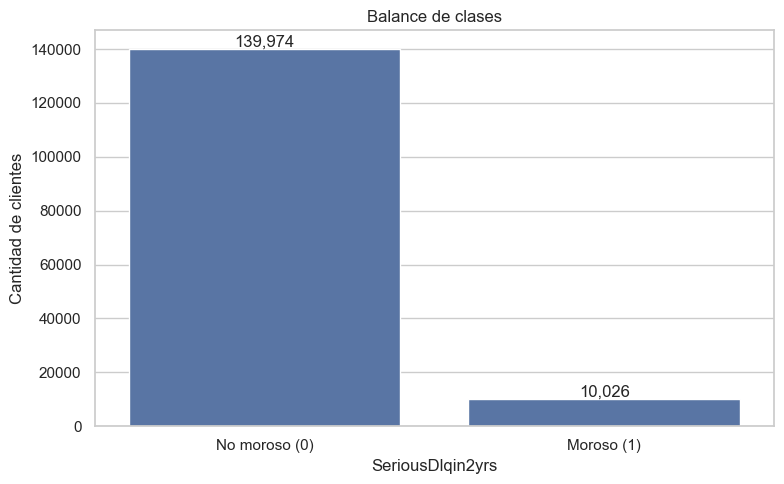

In [13]:
#gráficamente vamos a ver como se encuentra distribuida la variable objetivo
target = "SeriousDlqin2yrs"
conteo = df[target].value_counts()
prop = df[target].value_counts(normalize=True)
print(conteo)
print("\nProporción de morosos:", round(prop[1] * 100, 2), "%")

fig, ax = plt.subplots()
sns.barplot(x=conteo.index, y=conteo.values, ax=ax)
ax.set_xticklabels(["No moroso (0)", "Moroso (1)"])
ax.set_title("Balance de clases")
ax.set_ylabel("Cantidad de clientes")
for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

La variable objetivo presenta un fuerte desbalance de clases. El 6,68% pertenece a la clase 1 y el restante pertenece a la clase 0. Este desbalance deberá considerarse posteriormente tanto durante el entrenamiento como en la selección de métricas de evaluación, ya que la accuracy por sí sola podría resultar engañosa.

                    faltantes porcentaje
MonthlyIncome           29731     19.82%
NumberOfDependents       3924      2.62%


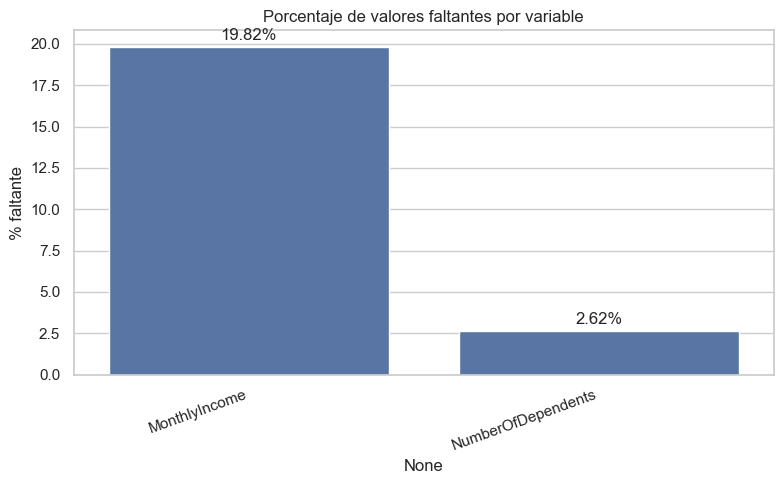

In [ ]:
#saber los valores faltantes de cada una de las columnas del df
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
pct = (faltantes / len(df) * 100).round(2)
resumen = pd.DataFrame({"faltantes": faltantes, "porcentaje": pct})
print(resumen.to_string(formatters={"porcentaje": lambda x: f"{x:.2f}%"}))

fig, ax = plt.subplots()
sns.barplot(x=resumen.index, y=resumen["porcentaje"], ax=ax)
ax.set_title("Porcentaje de valores faltantes por variable")
ax.set_ylabel("% faltante")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Los valores faltantes se concentran únicamente en MonthlyIncome y NumberOfDependents. El porcentaje de ausencia en MonthlyIncome es considerable (19,82%), mientras que en NumberOfDependents es relativamente bajo (2,62%).

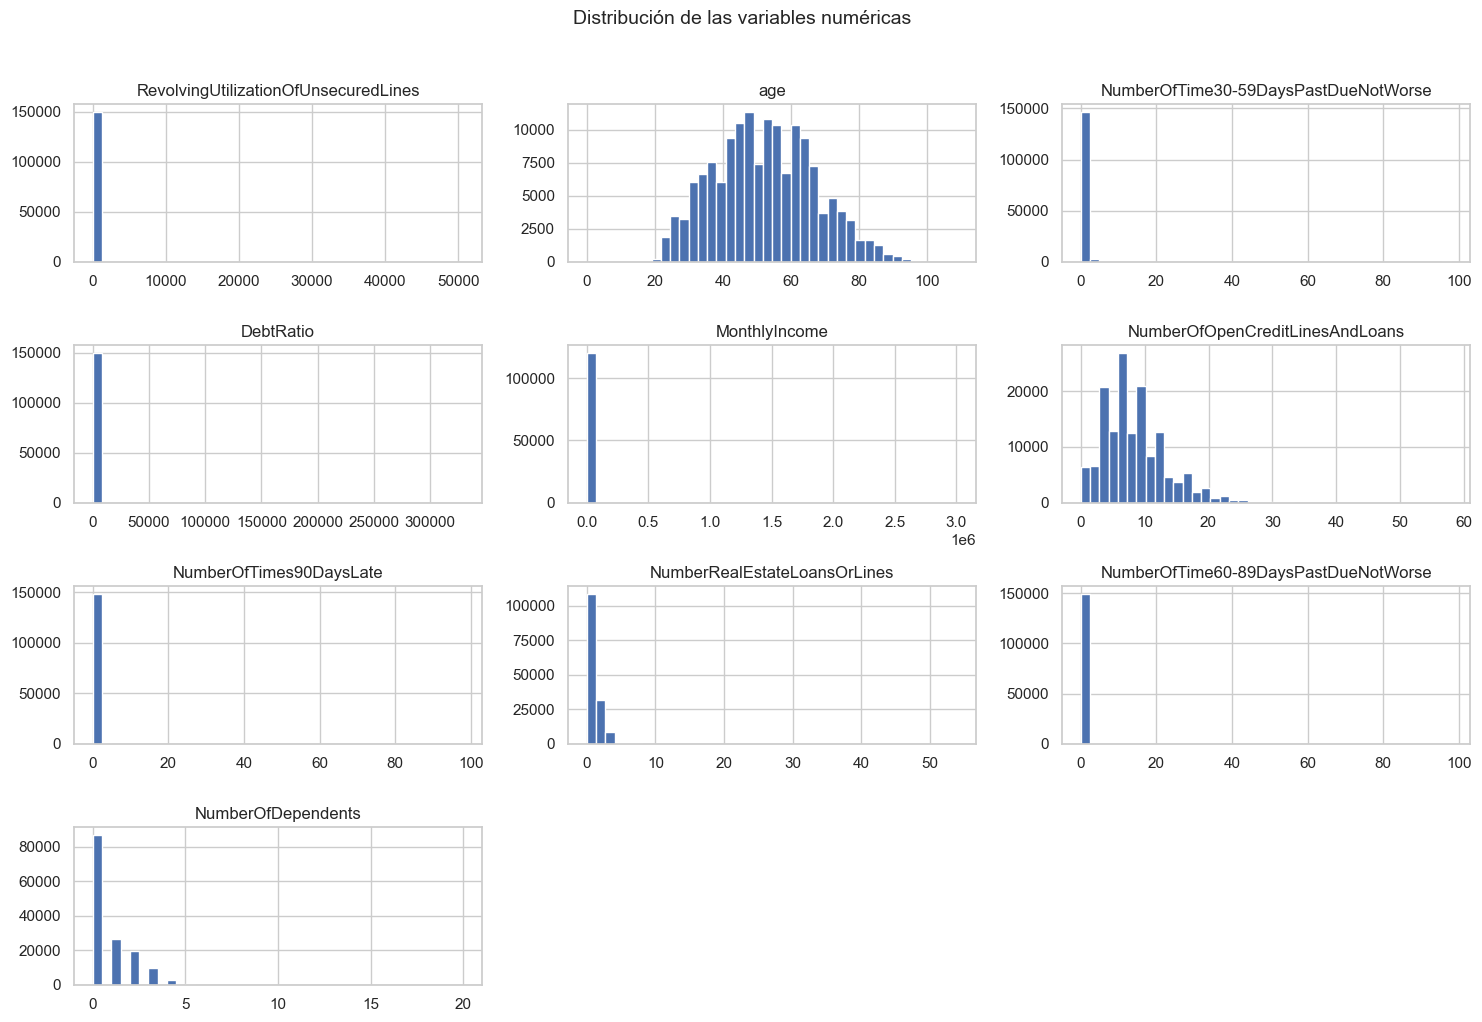

In [ ]:
#distribución de las variables numéricas
num_cols = df.drop(columns=[target]).columns
df[num_cols].hist(bins=40, figsize=(15, 10))
plt.suptitle("Distribución de las variables numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Las distribuciones muestran una importante asimetría en varias variables. RevolvingUtilizationOfUnsecuredLines, DebtRatio y MonthlyIncome presentan valores extremos que dificultan visualizar adecuadamente su distribución mediante histogramas convencionales. Las variables asociadas con eventos de mora presentan una fuerte concentración en cero, mientras que el número de líneas de crédito, préstamos inmobiliarios y dependientes se concentra principalmente en valores relativamente bajos.

In [25]:
#detección de valores atípicos
print("Edades mínimas:", sorted(df["age"].unique())[:5])
print("Clientes con age = 0:", (df["age"] == 0).sum())
print()
for c in ["NumberOfTime30-59DaysPastDueNotWorse",
          "NumberOfTimes90DaysLate",
          "NumberOfTime60-89DaysPastDueNotWorse"]:
    print(c)
    print("  valores anómalos (>=90):", df[df[c] >= 90][c].unique(),
          "| casos:", (df[c] >= 90).sum())

Edades mínimas: [np.int64(0), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Clientes con age = 0: 1

NumberOfTime30-59DaysPastDueNotWorse
  valores anómalos (>=90): [98 96] | casos: 269
NumberOfTimes90DaysLate
  valores anómalos (>=90): [98 96] | casos: 269
NumberOfTime60-89DaysPastDueNotWorse
  valores anómalos (>=90): [98 96] | casos: 269


Se identificó una única observación con edad igual a 0, mientras que la siguiente edad mínima registrada es 21 años. Esto sugiere que el valor 0 probablemente corresponde a una anomalía o dato inválido.
Las tres variables relacionadas con atrasos presentan valores anómalos de 96 y 98, con 269 observaciones en cada variable. La coincidencia en los valores y en el número de casos sugiere que podrían representar códigos especiales en lugar de cantidades reales de eventos de mora.

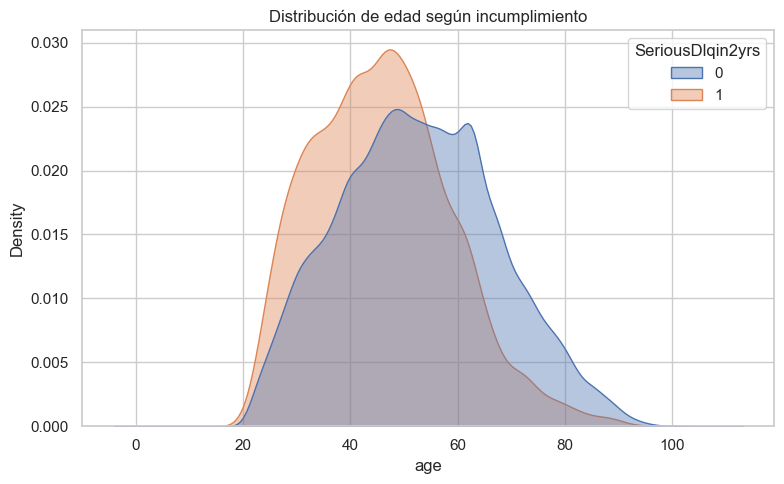

In [26]:
#distribución de edad según incumplimiento
fig, ax = plt.subplots()
sns.kdeplot(data=df, x="age", hue=target, common_norm=False, fill=True, alpha=0.4, ax=ax)
ax.set_title("Distribución de edad según incumplimiento")
plt.tight_layout()
plt.show()

La distribución de edad difiere entre clientes morosos y no morosos. Los clientes que presentan incumplimiento se concentran en edades relativamente menores, mientras que en edades más avanzadas aumenta la presencia relativa de clientes sin incumplimiento.

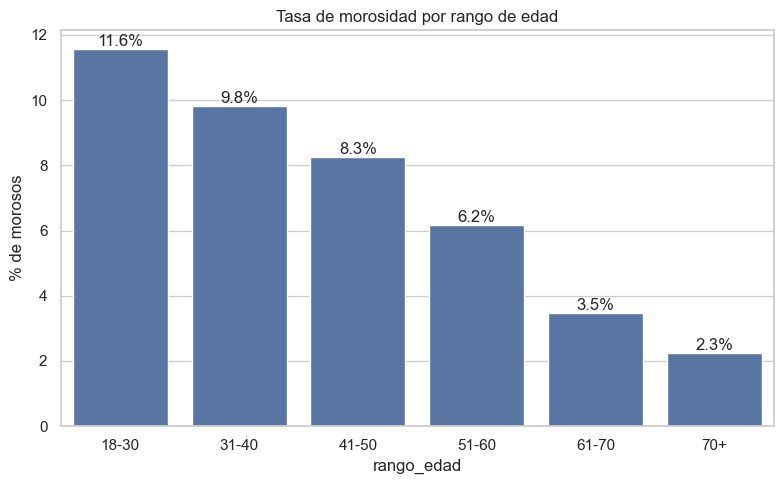

In [27]:
#tasa de morosidad por rango de edad
df_edad = df[df["age"] > 0].copy()
df_edad["rango_edad"] = pd.cut(df_edad["age"],
                               bins=[18, 30, 40, 50, 60, 70, 110],
                               labels=["18-30", "31-40", "41-50", "51-60", "61-70", "70+"])
tasa = df_edad.groupby("rango_edad")[target].mean() * 100

fig, ax = plt.subplots()
sns.barplot(x=tasa.index, y=tasa.values, ax=ax)
ax.set_title("Tasa de morosidad por rango de edad")
ax.set_ylabel("% de morosos")
for i, v in enumerate(tasa.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

Se observa una relación inversa consistente entre edad y morosidad. La tasa de incumplimiento disminuye progresivamente desde 11,6% en clientes de 18–30 años hasta 2,3% en clientes mayores de 70 años. La edad parece contener información relevante para predecir el riesgo crediticio.

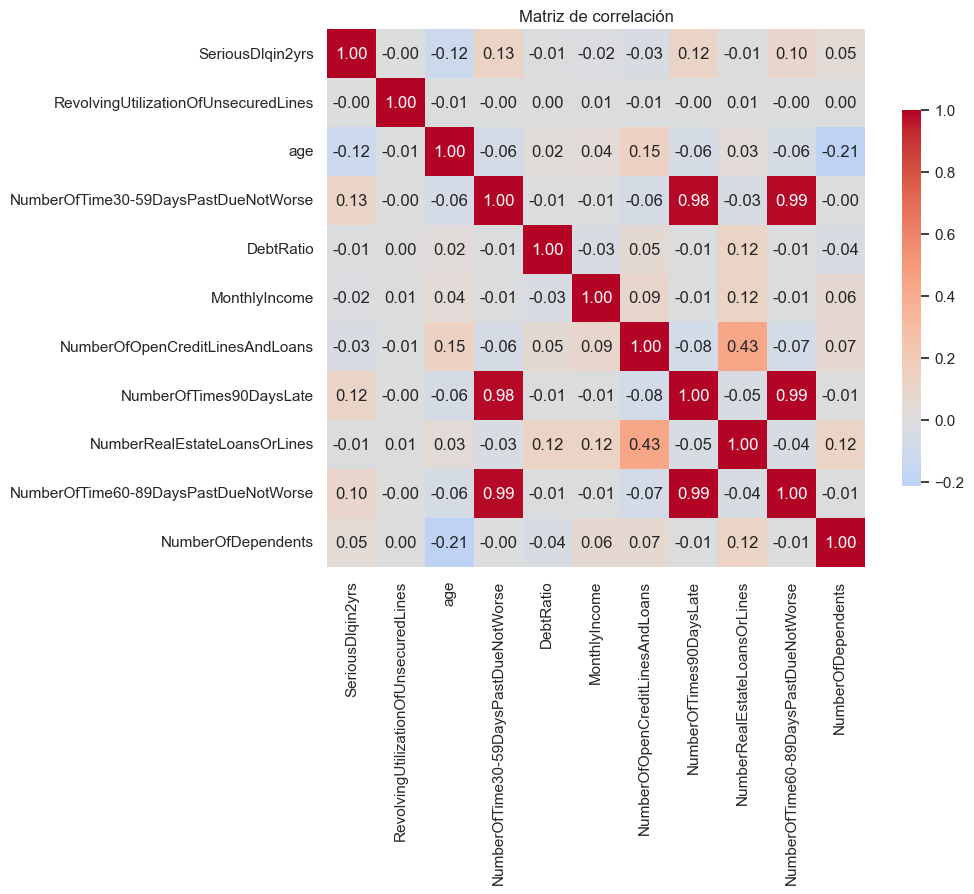

In [ ]:
#matriz de correlación
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

La matriz de correlación muestra relaciones relevantes entre las variables que registran diferentes tipos de atrasos, lo cual es esperable debido a que representan comportamientos crediticios relacionados. No se observan correlaciones lineales extremadamente altas entre la mayoría de las variables predictoras.

NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
age                                    -0.115386
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.019746
DebtRatio                              -0.007602
NumberRealEstateLoansOrLines           -0.007038
RevolvingUtilizationOfUnsecuredLines   -0.001802
Name: SeriousDlqin2yrs, dtype: float64


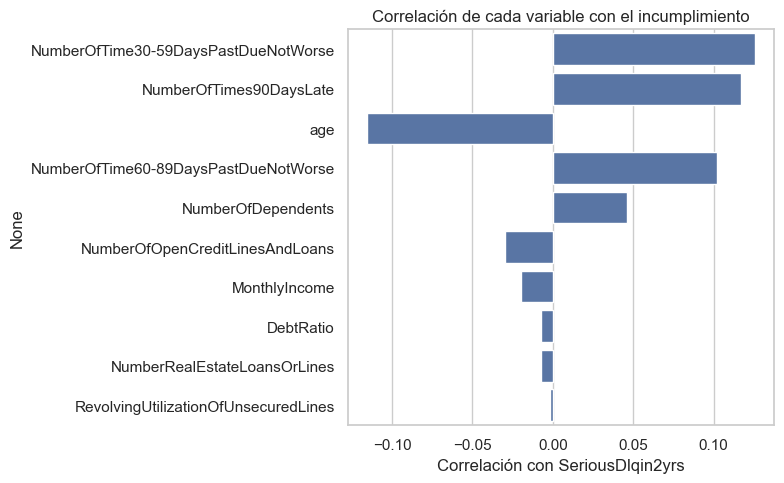

In [ ]:
#correlación contra la variable objetivo
corr_target = corr[target].drop(target).sort_values(key=abs, ascending=False)
print(corr_target)

fig, ax = plt.subplots()
sns.barplot(x=corr_target.values, y=corr_target.index, ax=ax)
ax.set_title("Correlación de cada variable con el incumplimiento")
ax.set_xlabel("Correlación con SeriousDlqin2yrs")
plt.tight_layout()
plt.show()

Las mayores correlaciones lineales con el incumplimiento corresponden a las variables relacionadas con atrasos, seguidas por la edad, que presenta una relación negativa. Sin embargo, las correlaciones individuales son moderadas o bajas, por lo que no deben utilizarse por sí solas para descartar variables. Algunas características pueden presentar relaciones no lineales con el riesgo que requieren análisis adicionales.

In [ ]:
#identificación de duplicados
df.duplicated().sum()

np.int64(609)

Se identificaron 609 registros duplicados.Aunque representan una proporción reducida del total, deberán revisarse antes del modelado para determinar si corresponden a observaciones repetidas o a clientes distintos con características idénticas.